<a href="https://colab.research.google.com/github/mishrasatyam9720-debug/calories-burnt-analysis/blob/main/calories_burnt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [6]:
df_1 = pd.read_csv("/content/calories.csv")
df_2=pd.read_csv("/content/exercise.csv")

In [7]:
df_1.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [8]:
df_2.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [9]:
df_1.shape

(15000, 2)

In [10]:
df_2.shape

(15000, 8)

In [11]:
df = pd.concat([df_2, df_1["Calories"]],axis=1)

In [12]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [13]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [14]:
sns.set()

In [15]:
df['Gender'].value_counts()

,count
Gender,
female,7553
male,7447


<Axes: xlabel='count', ylabel='Gender'>

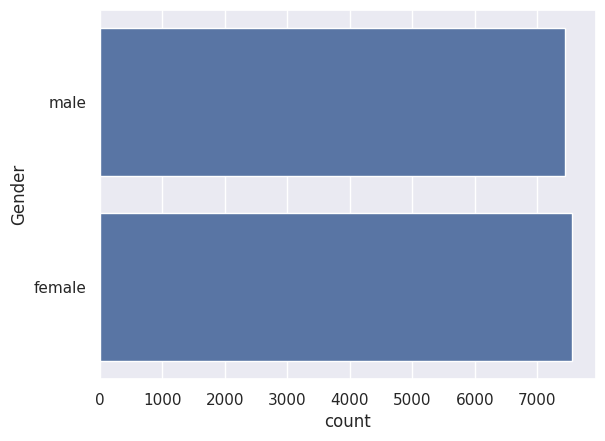

In [16]:
#wanna to see graphicallyyyyyyyyy -----
sns.countplot(df["Gender"])

/tmp/ipykernel_882/1681355075.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"])


<Axes: xlabel='Age', ylabel='Density'>

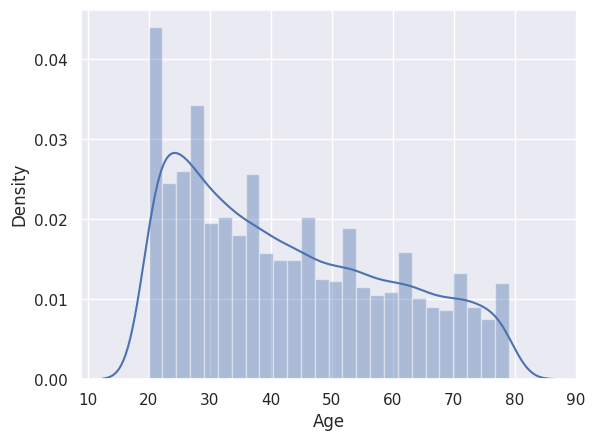

In [17]:
#wanna to seee crowd for every section by graph -------
sns.distplot(df["Age"])

/tmp/ipykernel_882/1870637031.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Height"])


<Axes: xlabel='Height', ylabel='Density'>

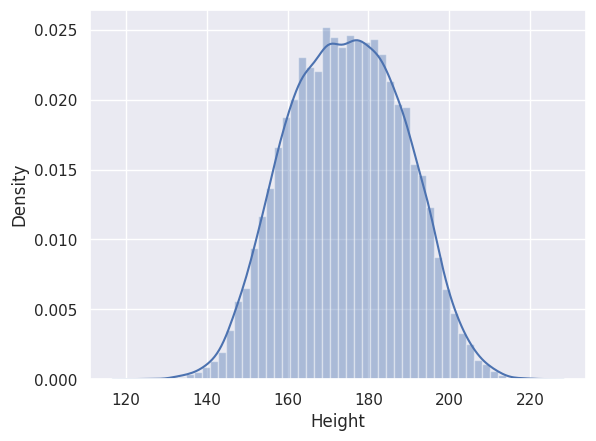

In [18]:
sns.distplot(df["Height"])

/tmp/ipykernel_882/2732350774.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"])


<Axes: xlabel='Age', ylabel='Density'>

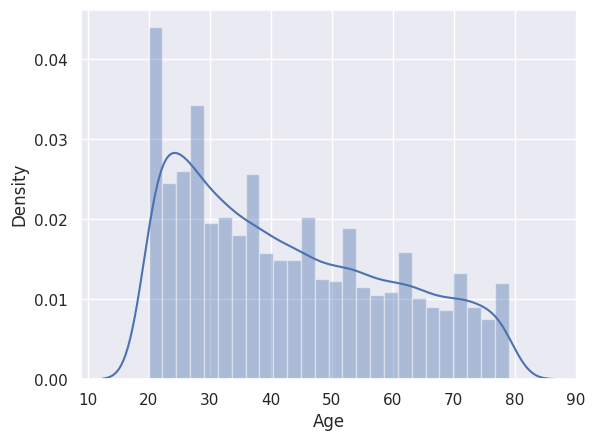

In [19]:
sns.distplot(df["Age"])

In [20]:
# replacing gender name into numeric data -------------
df.replace({"Gender":{"male":0,"female":1}},inplace= True)

/tmp/ipykernel_882/299811685.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Gender":{"male":0,"female":1}},inplace= True)


In [21]:
df.head(n=10)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
5,15130815,1,36,151.0,50.0,23.0,96.0,40.7,123.0
6,19602372,1,33,158.0,56.0,22.0,95.0,40.5,112.0
7,11117088,0,41,175.0,85.0,25.0,100.0,40.7,143.0
8,12132339,0,60,186.0,94.0,21.0,97.0,40.4,134.0
9,17964668,1,26,146.0,51.0,16.0,90.0,40.2,72.0


In [22]:
# correlation of every coloumn with another -------
correlation = df.corr()


<Axes: >

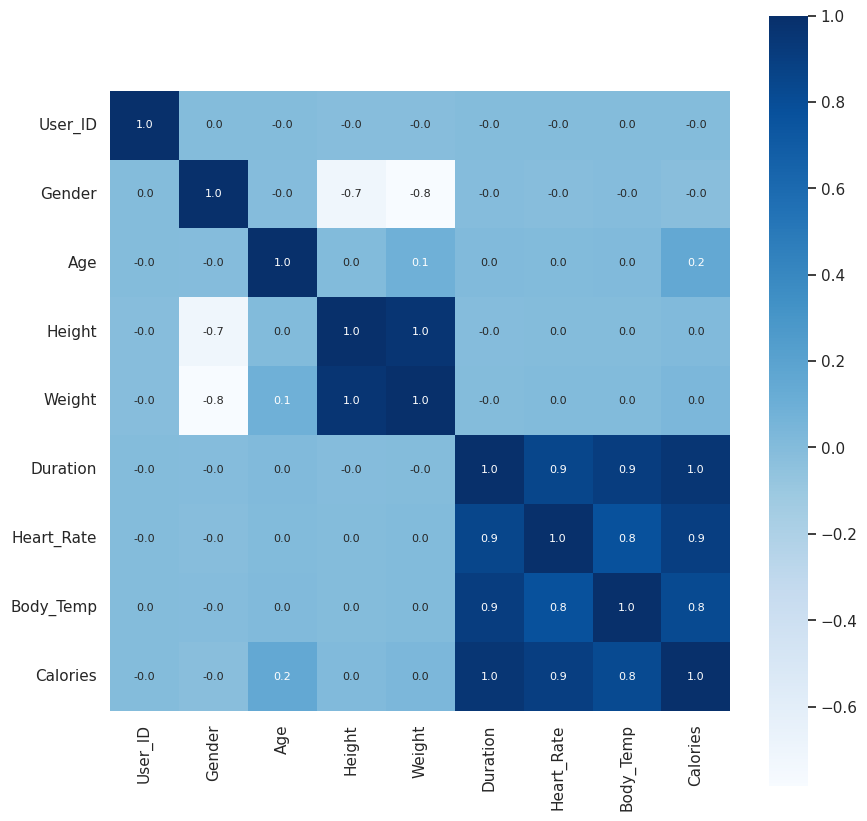

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,fmt='.1f',annot=True,annot_kws={'size':8},  cmap='Blues',cbar=True,square=True)

In [24]:
x = df.drop(['User_ID','Calories'],axis=1)
y = df['Calories']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [25]:
x_train.shape

(12000, 7)

In [26]:
x_test.shape

(3000, 7)

In [27]:
y_train.shape

(12000,)

In [28]:
y_test.shape

(3000,)

In [30]:
model=XGBRegressor()

In [32]:
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
# trining prediction accuracy ------------
training_data_prediction=model.predict(x_train)
r2_test_1=metrics.r2_score(y_train, training_data_prediction)
mean_absolute_error_training=metrics.mean_absolute_error(training_data_prediction,y_train)
print("prediction_r_test_traiining",r2_test_1)
print("mean_absolute_error_training",mean_absolute_error_training)

prediction_r_test_traiining 0.9995691477017405
mean_absolute_error_training 0.9322033420062313


In [45]:
# test_data_prediction acuuracy ---
test_data_prediction=model.predict(x_test)
r2_test=metrics.r2_score(test_data_prediction,y_test)
mean_absolute_error_testing=metrics.mean_absolute_error(test_data_prediction,y_test)
print("prediction_r_test_testing",r2_test)
print("mean_absolute_error_testing",mean_absolute_error_testing)



prediction_r_test_testing 0.9987986496259049
mean_absolute_error_testing 1.4833678883314132


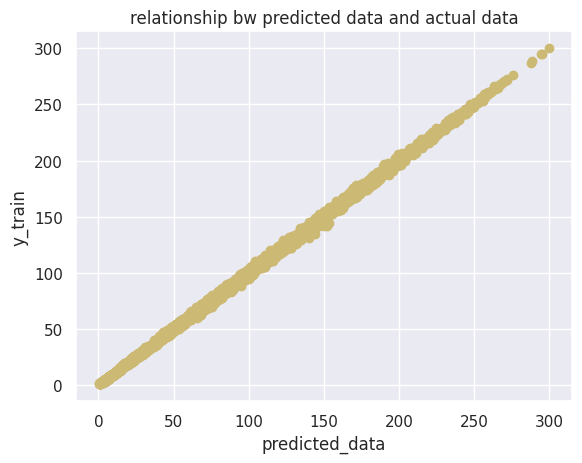

In [50]:
plt.scatter(training_data_prediction,y_train,color="y")
plt.xlabel("predicted_data")
plt.ylabel("y_train")
plt.title("relationship bw predicted data and actual data")
plt.show()


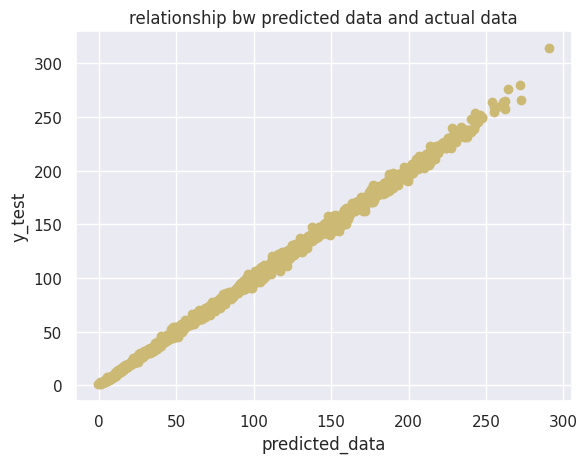

In [51]:
plt.scatter(test_data_prediction,y_test,color="y")
plt.xlabel("predicted_data")
plt.ylabel("y_test")
plt.title("relationship bw predicted data and actual data")
plt.show()

In [55]:
# have a some prediction -----
input_data=np.asarray([0, 68, 190.0, 94.0, 29.0, 105.0, 40.8]).reshape(1,-1)
prediction=model.predict(input_data)
prediction

array([236.13371], dtype=float32)